# Аналіз даних Titanic

**Набір даних:** Titanic Dataset  
**Мета:** провести первинний аналіз даних (EDA), перевірити якість даних, дослідити характеристики пасажирів та фактори, пов'язані з виживанням.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("titanic.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Загальна інформація про набір даних


In [2]:
print("Розмір:", df.shape)
print("\nСтовпці:")
print(df.columns.tolist())

print("\nТипи даних:")
print(df.dtypes)

print("\nЗагальна інформація:")
df.info()


Розмір: (891, 12)

Стовпці:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Типи даних:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Загальна інформація:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   

**Висновок:** на цьому етапі визначаємо кількість рядків і стовпців, назви ознак та їх типи даних.


## 2. Описова статистика


In [3]:
df.describe(include="all")


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


**Висновок:** описова статистика показує основні характеристики числових і категоріальних ознак: середні значення, розкид, мінімуми, максимуми та частоти.


## 3. Перевірка пропусків і дублікатів


In [4]:
print("Пропущені значення:")
print(df.isna().sum())

print("\nЧастка пропусків, %:")
print((df.isna().mean() * 100).round(2))

print("\nКількість дублікатів:", df.duplicated().sum())


Пропущені значення:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Частка пропусків, %:
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

Кількість дублікатів: 0


**Висновок:** перевірка пропусків і дублікатів допомагає оцінити якість даних перед подальшим аналізом.


## 4. Очищення даних


In [5]:
data = df.drop_duplicates().copy()

# Заповнюємо пропуски у віці медіаною
if "Age" in data.columns:
    data["Age"] = data["Age"].fillna(data["Age"].median())

# Заповнюємо пропуски у порту посадки модою
if "Embarked" in data.columns and data["Embarked"].isna().any():
    data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

# Заповнюємо пропуски у Fare медіаною, якщо вони є
if "Fare" in data.columns:
    data["Fare"] = data["Fare"].fillna(data["Fare"].median())

print(data.isna().sum())


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


**Висновок:** дублікати видалено, а пропуски в основних ознаках заповнено відповідними статистичними значеннями. `Cabin`, якщо вона має багато пропусків, не заповнюємо штучно для цього EDA.


## 5. Аналіз виживання


In [6]:
survival = data["Survived"].value_counts().sort_index()
survival_percent = data["Survived"].value_counts(normalize=True).sort_index() * 100

result = pd.DataFrame({
    "Кількість": survival,
    "Відсоток": survival_percent.round(2)
})
result


,Кількість,Відсоток
Survived,,
0,549,61.62
1,342,38.38


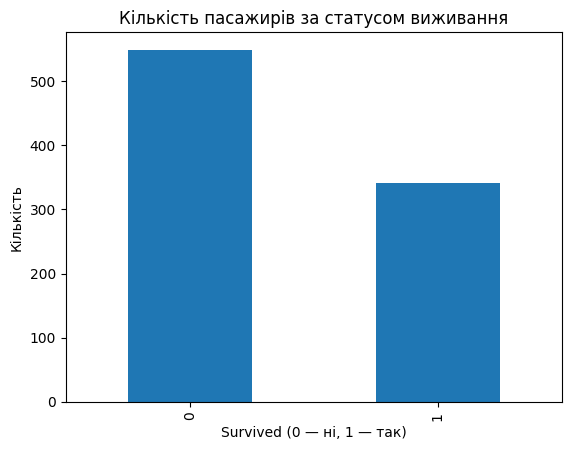

In [7]:
data["Survived"].value_counts().sort_index().plot(
    kind="bar",
    title="Кількість пасажирів за статусом виживання"
)
plt.xlabel("Survived (0 — ні, 1 — так)")
plt.ylabel("Кількість")
plt.show()


**Висновок:** порівнюємо кількість та частку пасажирів, які вижили і не вижили.


## 6. Виживання за статтю


In [8]:
sex_survival = data.groupby("Sex")["Survived"].agg(["count", "mean"])
sex_survival["mean"] = (sex_survival["mean"] * 100).round(2)
sex_survival.rename(columns={"count": "Кількість", "mean": "Вижили, %"})


,Кількість,"Вижили, %"
Sex,,
female,314,74.20
male,577,18.89


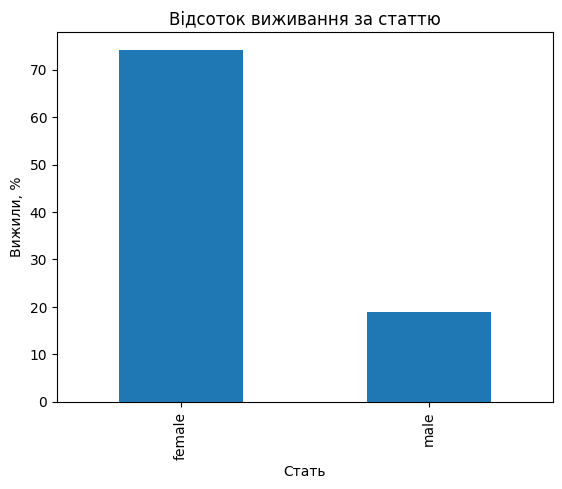

In [9]:
data.groupby("Sex")["Survived"].mean().mul(100).plot(
    kind="bar",
    title="Відсоток виживання за статтю"
)
plt.ylabel("Вижили, %")
plt.xlabel("Стать")
plt.show()


**Висновок:** таблиця та графік дозволяють порівняти рівень виживання чоловіків і жінок.


## 7. Виживання за класом квитка


In [10]:
class_survival = data.groupby("Pclass")["Survived"].agg(["count", "mean"])
class_survival["mean"] = (class_survival["mean"] * 100).round(2)
class_survival.rename(columns={"count": "Кількість", "mean": "Вижили, %"})


,Кількість,"Вижили, %"
Pclass,,
1,216,62.96
2,184,47.28
3,491,24.24


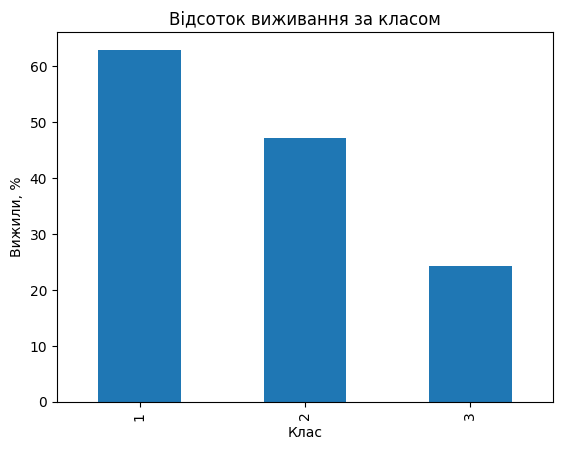

In [11]:
data.groupby("Pclass")["Survived"].mean().mul(100).plot(
    kind="bar",
    title="Відсоток виживання за класом"
)
plt.xlabel("Клас")
plt.ylabel("Вижили, %")
plt.show()


**Висновок:** аналіз показує, чи відрізняється ймовірність виживання пасажирів різних класів.


## 8. Аналіз віку


count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64


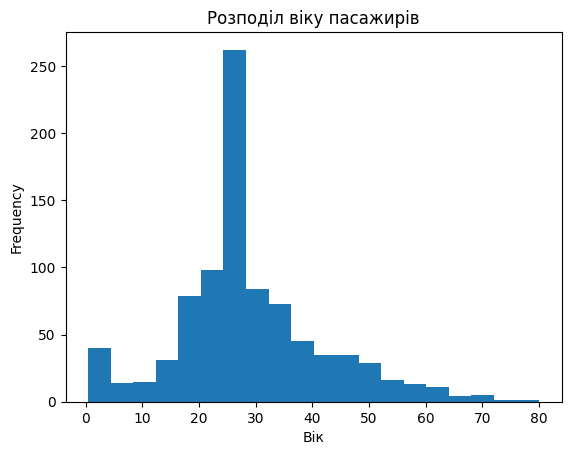

In [12]:
print(data["Age"].describe())

data["Age"].plot(
    kind="hist",
    bins=20,
    title="Розподіл віку пасажирів"
)
plt.xlabel("Вік")
plt.show()


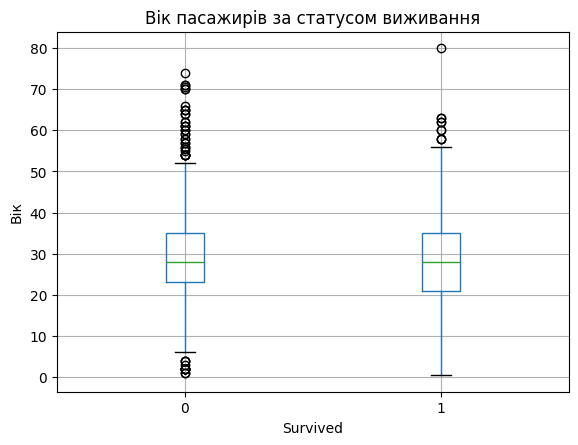

In [13]:
data.boxplot(column="Age", by="Survived")
plt.title("Вік пасажирів за статусом виживання")
plt.suptitle("")
plt.xlabel("Survived")
plt.ylabel("Вік")
plt.show()


**Висновок:** гістограма показує розподіл віку пасажирів, а boxplot дозволяє порівняти вік тих, хто вижив і не вижив.


## 9. Аналіз вартості квитка


count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


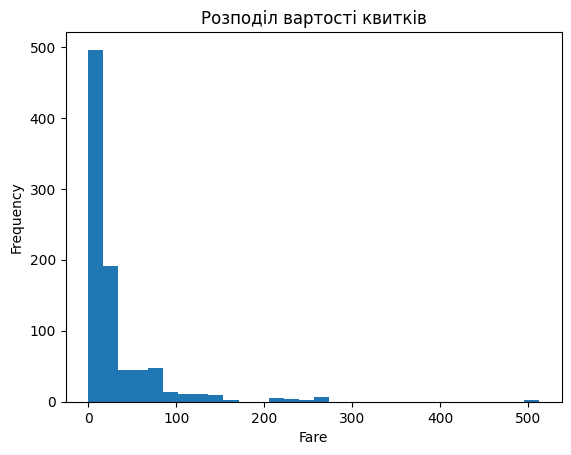

In [14]:
print(data["Fare"].describe())

data["Fare"].plot(
    kind="hist",
    bins=30,
    title="Розподіл вартості квитків"
)
plt.xlabel("Fare")
plt.show()


**Висновок:** розподіл `Fare` показує типові значення вартості квитків та наявність дорогих квитків, які можуть виглядати як викиди.


## 10. Виживання залежно від статі та класу


In [15]:
pivot = pd.pivot_table(
    data,
    values="Survived",
    index="Sex",
    columns="Pclass",
    aggfunc="mean"
) * 100

pivot.round(2)


Pclass,1,2,3
Sex,,,
female,96.81,92.11,50.00
male,36.89,15.74,13.54


**Висновок:** зведена таблиця одночасно показує вплив статі та класу квитка на частку пасажирів, які вижили.


## 11. Кореляція числових ознак


In [16]:
numeric_data = data.select_dtypes(include=np.number)
corr = numeric_data.corr()

corr.round(2)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.00,-0.01,-0.04,0.03,-0.06,-0.00,0.01
Survived,-0.01,1.00,-0.34,-0.06,-0.04,0.08,0.26
Pclass,-0.04,-0.34,1.00,-0.34,0.08,0.02,-0.55
Age,0.03,-0.06,-0.34,1.00,-0.23,-0.17,0.10
SibSp,-0.06,-0.04,0.08,-0.23,1.00,0.41,0.16
Parch,-0.00,0.08,0.02,-0.17,0.41,1.00,0.22
Fare,0.01,0.26,-0.55,0.10,0.16,0.22,1.00


In [17]:
print("Кореляція ознак із Survived:")
print(corr["Survived"].sort_values(ascending=False).round(3))


Кореляція ознак із Survived:
Survived       1.000
Fare           0.257
Parch          0.082
PassengerId   -0.005
SibSp         -0.035
Age           -0.065
Pclass        -0.338
Name: Survived, dtype: float64


**Висновок:** кореляція допомагає оцінити лінійний зв'язок числових ознак із `Survived`. Водночас категоріальні ознаки, наприклад `Sex`, потрібно аналізувати окремо або попередньо кодувати.


## 12. Підсумковий висновок


In [18]:
print("Кількість пасажирів:", len(data))
print("Загальний відсоток виживання:", round(data["Survived"].mean() * 100, 2), "%")
print("\nВиживання за статтю, %:")
print((data.groupby("Sex")["Survived"].mean() * 100).round(2))
print("\nВиживання за класом, %:")
print((data.groupby("Pclass")["Survived"].mean() * 100).round(2))


Кількість пасажирів: 891
Загальний відсоток виживання: 38.38 %

Виживання за статтю, %:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

Виживання за класом, %:
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


### Загальний висновок

Під час аналізу було досліджено структуру та якість набору даних Titanic, перевірено пропущені значення й дублікати та виконано базове очищення. Було проаналізовано загальну частку виживання, а також її залежність від статі, класу квитка, віку та вартості квитка.

Результати таблиць і графіків дають змогу визначити, які групи пасажирів мали вищий рівень виживання. Для подальшого машинного навчання корисними ознаками можуть бути `Pclass`, `Sex`, `Age`, `Fare`, `SibSp`, `Parch` та `Embarked`. Перед побудовою моделі категоріальні ознаки потрібно закодувати, а preprocessing виконувати без використання інформації з тестової вибірки.
